In [1]:
print("Hello")

Hello


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
img_path = "example_images/h_1000002_12.exr"
img = cv2.imread(img_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
print(img.shape)
print(img.dtype)
print(img[0, 0, 0])

(1440, 2560, 3)
float32
0.29934692


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01083374..1.1378174].


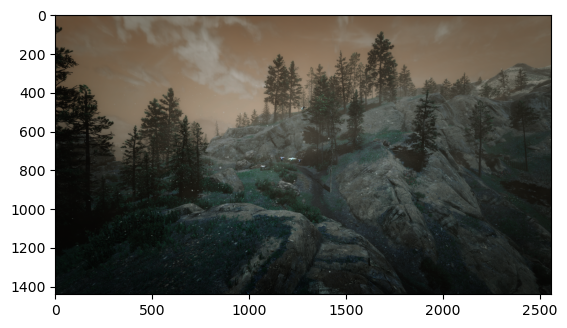

In [4]:
# plot image using matplotlib
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
*************** Input Stats ***************
Image shape: (1440, 2560, 3)
Image dtype: float32
Pixel value range: 54.168701171875 to 5689.0869140625
Mean pixel value: 1215.8004150390625
Standard deviation of pixel values: 787.6148681640625
Image shape: (1440, 2560, 3)
Image dtype: float64
Pixel value range: 28.7 to 4236.4
Mean pixel value: 902.3785256799773
Standard deviation of pixel values: 585.1272025564343
*************** Final Stats ***************
Image shape: (1440, 2560, 3)
Image dtype: uint8
Pixel value range: 0 to 32
Mean pixel value: 6.342957175925926
Standard deviation of pixel values: 4.457360995431529


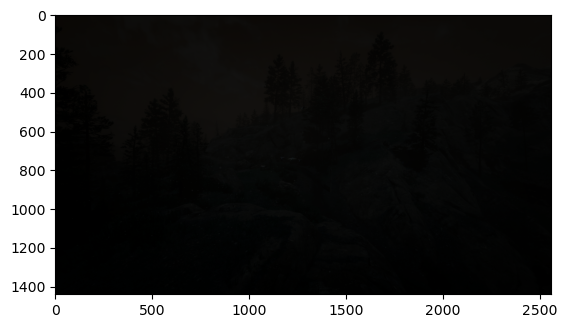

In [19]:
# Autoreload files
%load_ext autoreload
%autoreload 2

# import camera simulation code
import camera_simulation as sim
img_path = "example_images/h_1000002_12.exr"
depth_path = "example_images/d_1000002.exr"

img = cv2.imread(img_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
depth = cv2.imread(depth_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)

if img is None:
    print(f"Failed to load image from {img_path}")

else:
    # create camera simulation object
    camera_sim = sim.CameraSimulation(iso = sim.iso_values[0], log=True)
    # simulate camera response
    simulated_img = camera_sim.simulate_image(img*5000, depth)
    # plot simulated image
    plt.imshow(simulated_img)
    plt.show()

250 0.25 5.0
250 0.25 9.0
250 0.25 16.0
250 0.016666666666666666 5.0
250 0.016666666666666666 9.0
250 0.016666666666666666 16.0
250 0.001 5.0
250 0.001 9.0
250 0.001 16.0
2000 0.25 5.0
2000 0.25 9.0
2000 0.25 16.0
2000 0.016666666666666666 5.0
2000 0.016666666666666666 9.0
2000 0.016666666666666666 16.0
2000 0.001 5.0
2000 0.001 9.0
2000 0.001 16.0
16000 0.25 5.0
16000 0.25 9.0
16000 0.25 16.0
16000 0.016666666666666666 5.0
16000 0.016666666666666666 9.0
16000 0.016666666666666666 16.0
16000 0.001 5.0
16000 0.001 9.0
16000 0.001 16.0


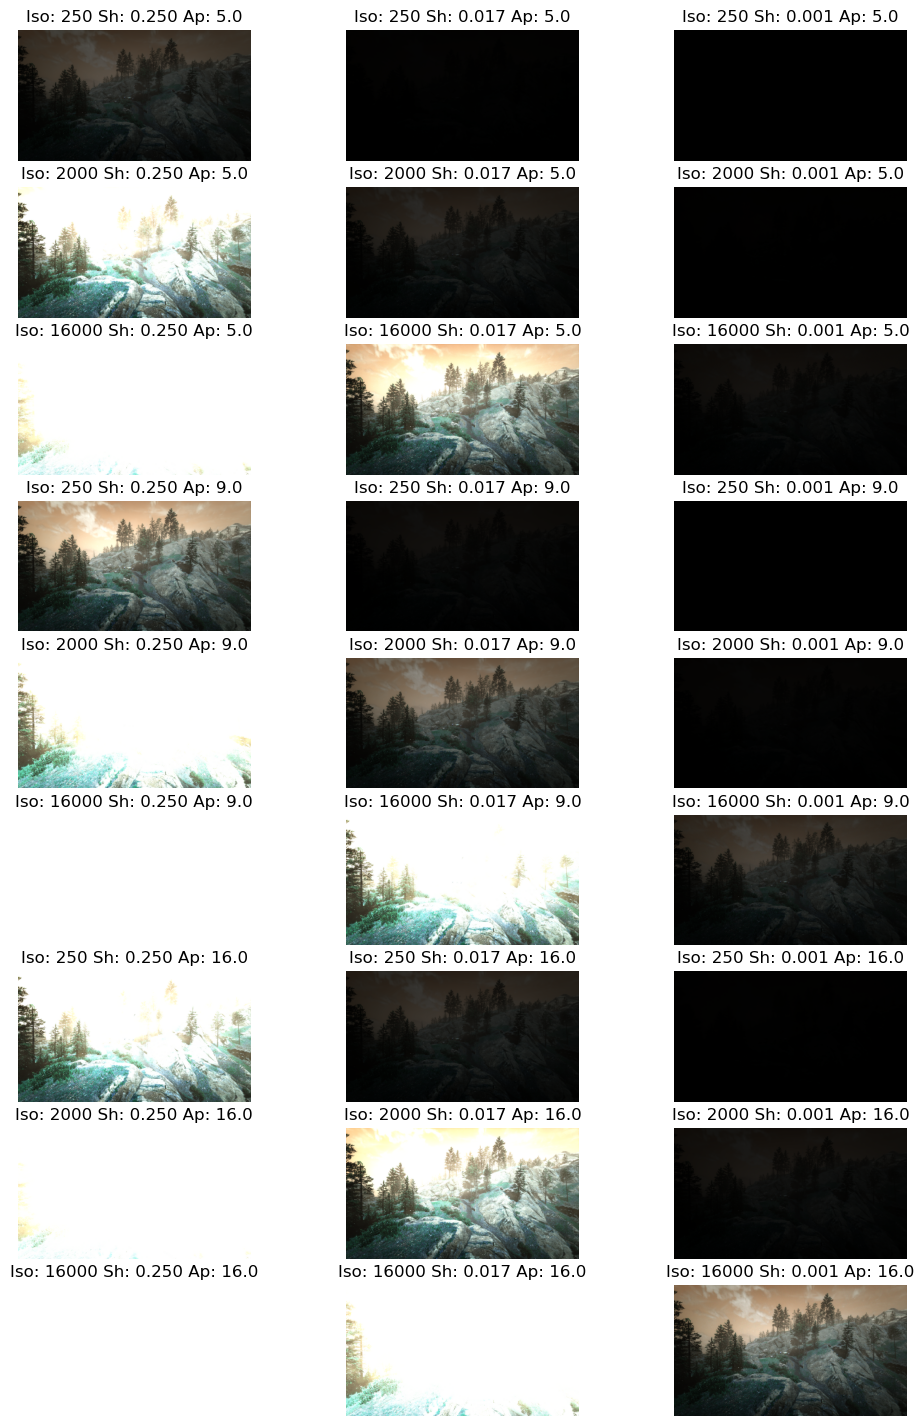

In [34]:
fig, ax = plt.subplots(9,3, figsize=(12,18))

cam = sim.CameraSimulation(log=False)
images = []

for i in range(3):
    for j in range(3):
        for k in range(3):
            iso = sim.iso_values[i]
            shutter_speed = sim.shutter_speed_values[j]
            aperture = sim.aperture_values[k]
            print(iso, shutter_speed, aperture)
            cam.set_parameters(iso=iso, shutter_speed=shutter_speed, aperture=aperture)
            simulation = cam.simulate_image(img*5000, depth)
            ax[k*3+i][j].imshow(simulation)
            ax[k*3+i][j].axis('off')
            ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")



plt.show()
